In [2]:
import re
import math
from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from einops import rearrange
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

from nanofm.utils.checkpoint import load_model_from_safetensors
from nanofm.data.multimodal.simple_multimodal_dataset import SimpleMultimodalDataset
from nanofm.data.multimodal.masking import SimpleMultimodalMasking

from huggingface_hub import snapshot_download
from cosmos_tokenizer.image_lib import ImageTokenizer
from fourm.vq.vqvae import DiVAE

device = 'cuda' if torch.cuda.is_available() else 'cpu'

snapshot_download(
    repo_id='nvidia/Cosmos-0.1-Tokenizer-DI16x16', 
    local_dir='/tmp/nvidia000/Cosmos-0.1-Tokenizer-DI16x16'
)

image_tokenizer = ImageTokenizer(
    checkpoint_enc='/tmp/nvidia000/Cosmos-0.1-Tokenizer-DI16x16/encoder.jit',
    checkpoint_dec='/tmp/nvidia000/Cosmos-0.1-Tokenizer-DI16x16/decoder.jit',
).to(device)

tok_edge_fourm = DiVAE.from_pretrained('EPFL-VILAB/4M_tokenizers_edge_8k_224-512').to(device)

ckpt_path = '/scratch/tmaillar/outputs/nano4M/multiclevr_d6-6w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

encoder.jit:   0%|          | 0.00/70.2M [00:00<?, ?B/s]

autoencoder.jit:   0%|          | 0.00/169M [00:00<?, ?B/s]

decoder.jit:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

model_config.yaml:   0%|          | 0.00/92.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

44.322304M parameters


In [4]:
def token_ids_to_image(token_ids, image_tokenizer, to_pil=False):
    n_tokens = token_ids.numel()
    side = int(math.sqrt(n_tokens))
    token_ids = token_ids.reshape(1,side,side).to(device)
    reconst = image_tokenizer.decode(token_ids)
    reconst = (reconst[0].clamp(-1,1).float().cpu() + 1) / 2
    if to_pil:
        reconst = TF.to_pil_image(reconst)
    return reconst

def canny_token_ids_to_image(token_ids, to_pil=False):
    n_tokens = token_ids.numel()
    side = int(math.sqrt(n_tokens))
    token_ids = token_ids.reshape(1,side,side).to(device)
    with torch.no_grad():
        reconst = tok_edge_fourm.decode_tokens(token_ids, image_size=256)
    reconst = reconst.squeeze().cpu().float()
    if to_pil:
        reconst = TF.to_pil_image(reconst)
    return reconst
    
def get_modality_with_mask(data_dict, mod_name, mask_type=None):
    tokens = data_dict['unmasked_data_dict'][mod_name].clone()
    L = tokens.shape[0]
    if mask_type == 'input':
        modality_mask = data_dict['enc_modalities'] == modalities.index(mod_name)
        modality_mask = modality_mask & data_dict['enc_pad_mask']
        modality_indices = data_dict['enc_positions'][modality_mask]
    elif mask_type == 'target':
        modality_mask = data_dict['dec_modalities'] == modalities.index(mod_name)
        modality_mask = modality_mask & data_dict['dec_pad_mask']
        modality_indices = data_dict['dec_positions'][modality_mask]
    elif mask_type is None:
        modality_indices = torch.arange(L)
    else:
        raise ValueError()
    mask = torch.zeros(L, dtype=torch.bool)
    mask[modality_indices] = True # True = input, False = masked out
    return tokens, mask

def get_masked_image(img, mask):
    mask = mask.reshape(1,1,16,16).float()
    mask = F.interpolate(mask, (256,256), mode='nearest')[0,0].bool()
    img[:,~mask] = 0
    img = img.permute(1,2,0)
    return img

def plot_data_dict_with_mask(data_dict, mask_type=None):
    # Scene description
    tokens, mask = get_modality_with_mask(data_dict, 'scene_desc', mask_type=mask_type)
    n_scene_desc = mask.sum().item()
    tokens[~mask] = 62 # Simply plot masked out regions as underscores
    print(f'Scene description: {dataset.text_tokenizer.decode(tokens)}\n\n')
    
    fig = plt.figure(figsize=(10,4))
    grid = ImageGrid(fig, 111, nrows_ncols=(1, 3), axes_pad=0.1)
    
    # RGB
    tokens, mask = get_modality_with_mask(data_dict, 'tok_rgb@256', mask_type=mask_type)
    n_rgb = mask.sum().item()
    img = get_masked_image(token_ids_to_image(tokens, image_tokenizer), mask)
    grid[0].imshow(img)
    grid[0].set_title('RGB')
    
    # Depth
    tokens, mask = get_modality_with_mask(data_dict, 'tok_depth@256', mask_type=mask_type)
    n_depth = mask.sum().item()
    img = get_masked_image(token_ids_to_image(tokens, image_tokenizer), mask)
    grid[1].imshow(img)
    grid[1].set_title('Depth')
    
    # Normals
    tokens, mask = get_modality_with_mask(data_dict, 'tok_normal@256', mask_type=mask_type)
    n_normal = mask.sum().item()
    img = get_masked_image(token_ids_to_image(tokens, image_tokenizer), mask)
    grid[2].imshow(img)
    grid[2].set_title('Normals')
    
    plt.show()
    
    if mask_type is not None:
        print()
        print(f'Num. scene_desc tokens: {n_scene_desc}')
        print(f'Num. tok_rgb@256 tokens: {n_scene_desc}')
        print(f'Num. tok_depth@256 tokens: {n_depth}')
        print(f'Num. tok_normal@256 tokens: {n_normal}')
        print('-'*32)
        total_tokens = n_scene_desc + n_rgb + n_depth + n_normal
        print(f'Total tokens: {total_tokens}')

In [5]:
modalities=["tok_rgb@256", "tok_depth@256", "tok_normal@256", "scene_desc", "tok_canny@256"]
dataset = SimpleMultimodalDataset(
    root_dir='/work/com-304/datasets/clevr_com_304/',
    split='test',
    modalities=modalities,
    sample_from_k_augmentations=1,
    text_tokenizer_path='gpt2',
    text_max_length=256,
    transforms=None, # No transforms
    modality_paths={'tok_canny@256': '/scratch/tmaillar/canny/val'},
)

def construct_input_from_sample(dataset, idx, input_modality):
    input_tensor = dataset[idx][input_modality]
    n_tokens_input = input_tensor.shape[0]
    enc_input_tokens = input_tensor.unsqueeze(0).to(device)
    enc_input_positions = torch.arange(n_tokens_input, device=device).unsqueeze(0)
    enc_input_modalities = modalities.index(input_modality) * torch.ones(1, n_tokens_input, device=device, dtype=torch.long)
    return enc_input_tokens, enc_input_positions, enc_input_modalities

def show_modality(tokens, modality):
    if modality == 'scene_desc':
        print(dataset.text_tokenizer.decode(tokens[0]))
    elif modality == 'tok_canny@256':
        canny_token_ids_to_image(tokens, to_pil=True).show()
    else:
        token_ids_to_image(tokens, image_tokenizer, to_pil=True).show()

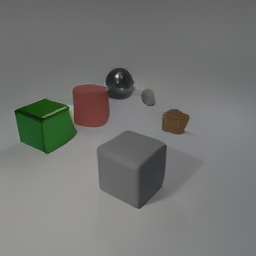

/home/deriaz/.local/lib/python3.10/site-packages/fourm/vq/scheduling/diffusion_pipeline.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


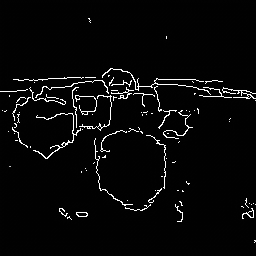

In [4]:
input_modality = 'tok_rgb@256'
sample_idx = 4 # Change this to sample_idx = 4
x_tokens, x_positions, x_modalities = construct_input_from_sample(dataset, idx=sample_idx, input_modality=input_modality)
show_modality(x_tokens, input_modality)

target_mod = 'tok_canny@256'
num_steps, temp, top_p, top_k = 6, 0.001, 0.0, 1.0
pred_tokens, x_tokens, x_positions, x_modalities = model.generate_one_modality_roar(
    x_tokens, x_positions, x_modalities, target_mod=target_mod,
    num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k,
)
show_modality(pred_tokens, target_mod)

In [6]:
def generate_with_chain(dataset, idx, input_modality, mod_chain, num_steps, temps, top_ps, top_ks, with_show=True):

    x_tokens, x_positions, x_modalities = construct_input_from_sample(dataset, idx=idx, input_modality=input_modality)

    if with_show:
        show_modality(x_tokens, input_modality)

    for mod in range(len(mod_chain)):

        target_mod = mod_chain[mod]
        steps, temp, top_p, top_k = num_steps[mod], temps[mod], top_ps[mod], top_ks[mod]

        pred_tokens, x_tokens, x_positions, x_modalities = model.generate_one_modality_roar(
        x_tokens, x_positions, x_modalities, target_mod=target_mod,
        num_steps=steps, temp=temp, top_p=top_p, top_k=top_k,
        )

        if with_show:
            show_modality(pred_tokens, target_mod)

    return pred_tokens, target_mod

[SOS]Object 1 - Position: x=9 y=50 Shape: sphere Color: purple Material: metal. Object 2 - Position: x=36 y=39 Shape: cylinder Color: blue Material: rubber. Object 3 - Position: x=48 y=58 Shape: sphere Color: purple Material: metal. Object 4 - Position: x=67 y=52 Shape: sphere Color: purple Material: metal. Object 5 - Position: x=76 y=46 Shape: sphere Color: blue Material: metal. Object 6 - Position: x=54 y=44 Shape: sphere Color: brown Material: rubber. [EOS][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][

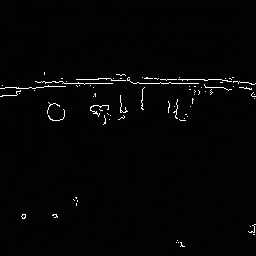

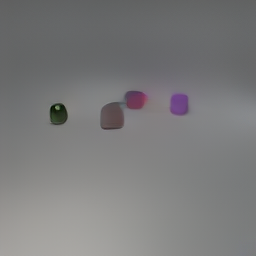

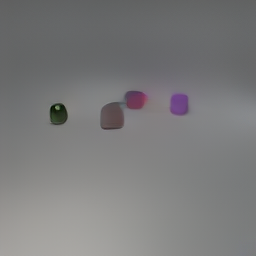

In [7]:

sample_idx = 0
input_modality = "scene_desc"
mod_chain = ["tok_canny@256","tok_rgb@256"]
num_steps = [8,8]
temps = [0.01, 0.01]
top_ps = [0.2, 0.2]
top_ks = [0.0, 0.0]

pred_token, target_mod = generate_with_chain(
    dataset=dataset,
    idx=sample_idx,
    input_modality=input_modality,
    mod_chain=mod_chain,
    num_steps=num_steps,
    temps=temps,
    top_ps=top_ps,
    top_ks=top_ks,
    with_show=True)

reconst = token_ids_to_image(pred_token, image_tokenizer, to_pil=True)

display(reconst)

### Image Generation scene desc to canny to rgb

In [12]:
directory_path = "/scratch/deriaz/scene_desc_to_canny_to_rgb"

reconst.save(f"{directory_path}/image.png")

In [13]:
from tqdm import tqdm

sample_idx = 0
input_modality = "scene_desc"
mod_chain = ["tok_canny@256","tok_rgb@256"]
num_steps = [8,8]
temps = [0.01, 0.01]
top_ps = [0.2, 0.2]
top_ks = [0.0, 0.0]

directory_path = "/scratch/deriaz/scene_desc_to_canny_to_rgb"

In [14]:
for i in tqdm(range(5000)):
    pred_token, target_mod = generate_with_chain(
        dataset=dataset,
        idx=i,
        input_modality=input_modality,
        mod_chain=mod_chain,
        num_steps=num_steps,
        temps=temps,
        top_ps=top_ps,
        top_ks=top_ks,
        with_show=False)

    reconst = token_ids_to_image(pred_token, image_tokenizer, to_pil=True)

    reconst.save(f"{directory_path}/fromscenedesctocanny{i:04d}.png")

100%|███████████████████████████████████████████████████████████████████████████████| 5000/5000 [11:47<00:00,  7.07it/s]


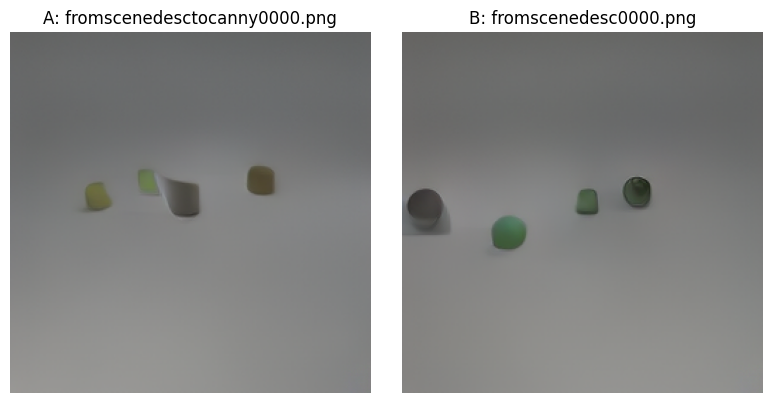

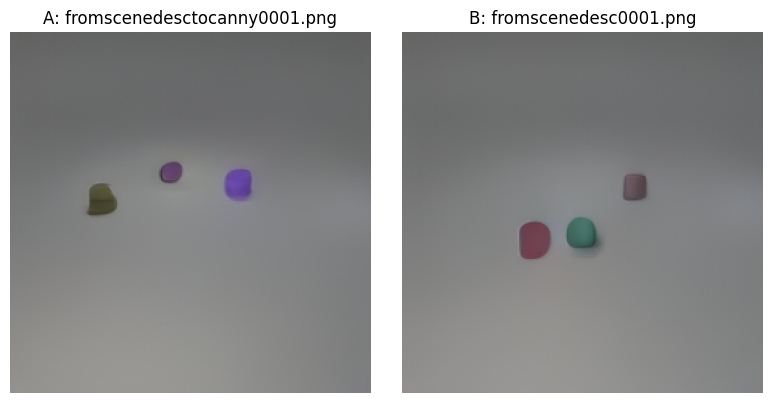

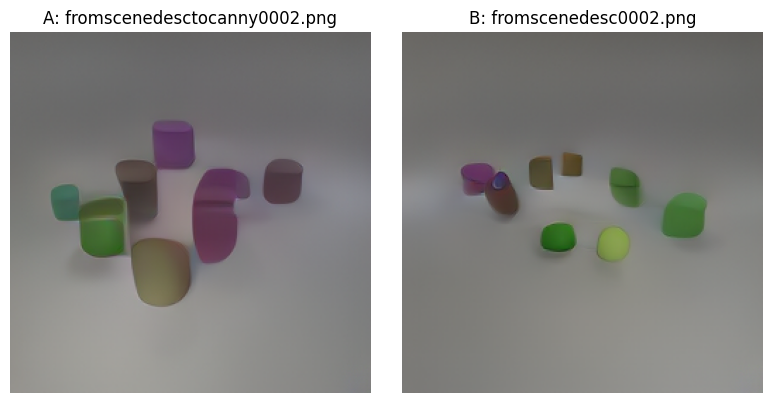

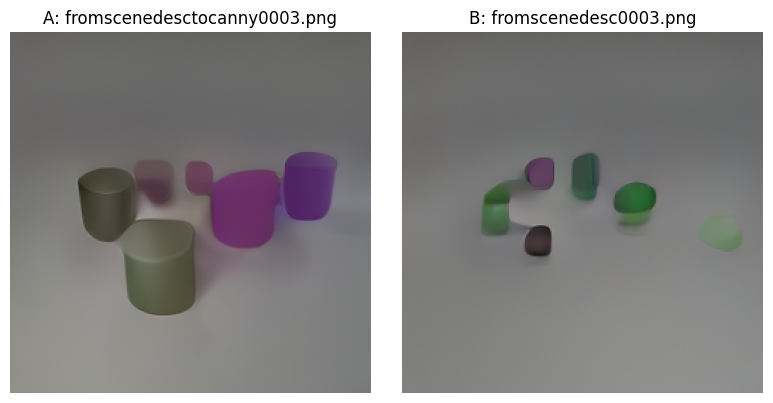

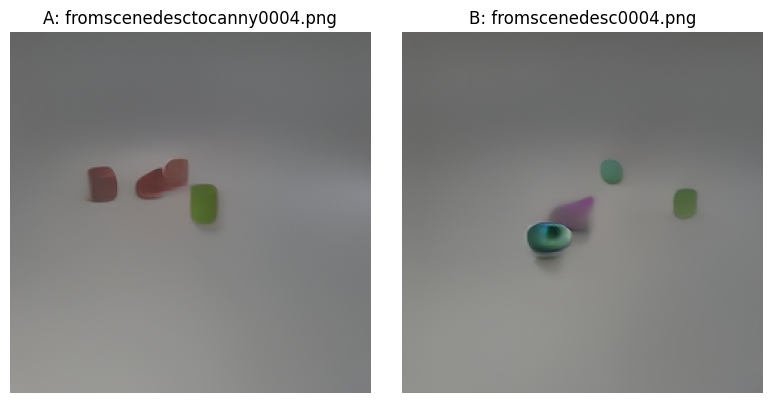

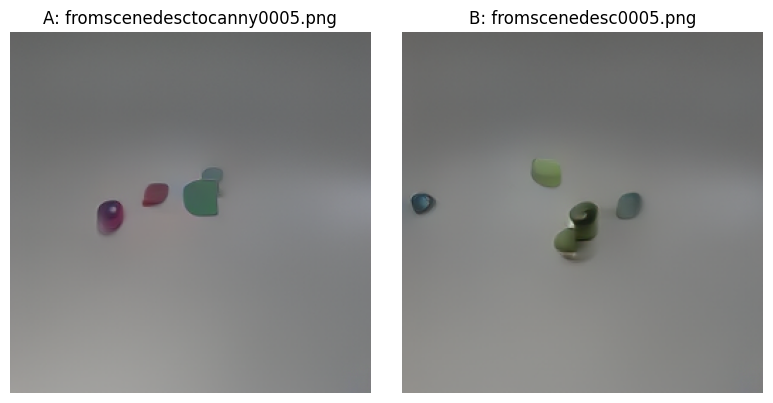

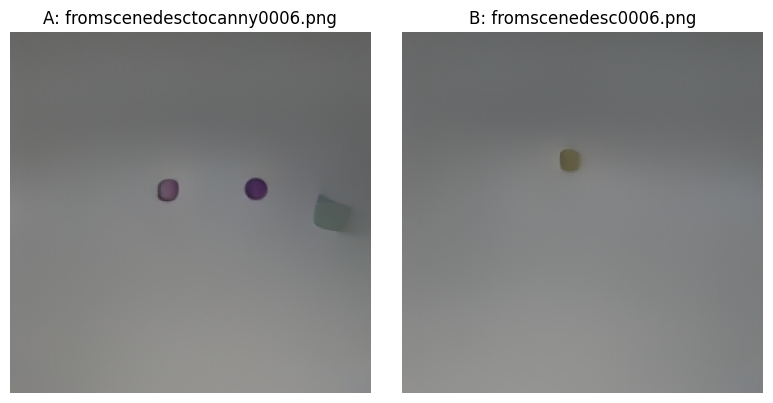

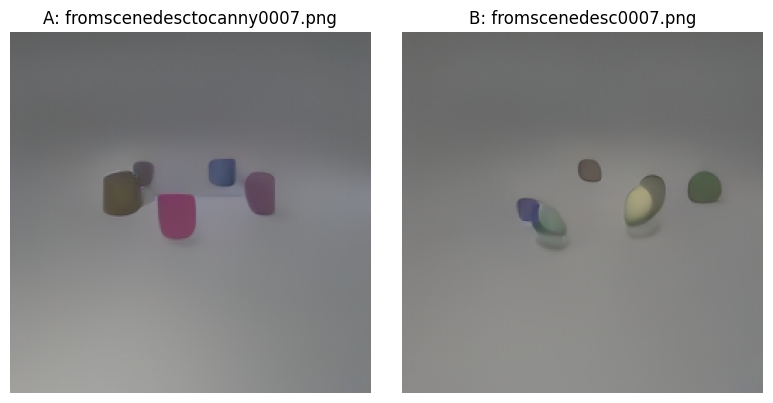

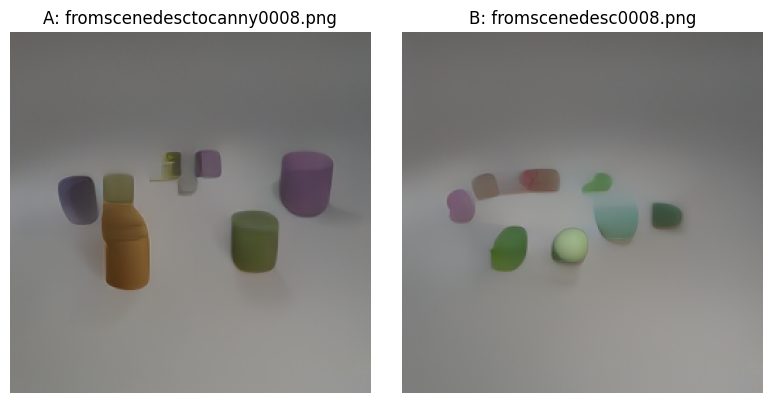

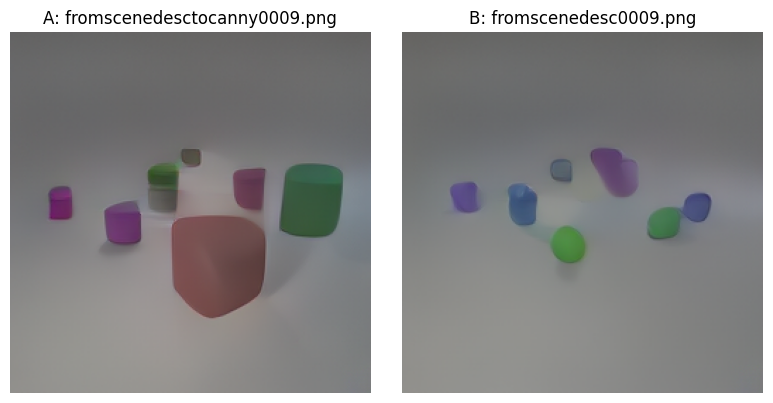

In [15]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

dir_a = Path("/scratch/deriaz/scene_desc_to_canny_to_rgb")
dir_b = Path("/scratch/deriaz/scene_desc_to_rgb")

files_a = sorted(list(dir_a.glob("*.png")))
files_b = sorted(list(dir_b.glob("*.png")))

n = 10

for i in range(n):
    img_a = Image.open(files_a[i])
    img_b = Image.open(files_b[i])

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img_a)
    plt.title(f"A: {files_a[i].name}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img_b)
    plt.title(f"B: {files_b[i].name}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### Image generation depth->RGB VS depth->Canny->RGB

In [7]:
from tqdm import tqdm

sample_idx = 0
input_modality = "tok_depth@256"
mod_chain = ["tok_rgb@256"]
num_steps = [8,8]
temps = [0.01, 0.01]
top_ps = [0.2, 0.2]
top_ks = [0.0, 0.0]

directory_path = "/scratch/deriaz/depth_to_rgb"

In [8]:
for i in tqdm(range(5000)):
    pred_token, target_mod = generate_with_chain(
        dataset=dataset,
        idx=i,
        input_modality=input_modality,
        mod_chain=mod_chain,
        num_steps=num_steps,
        temps=temps,
        top_ps=top_ps,
        top_ks=top_ks,
        with_show=False)

    reconst = token_ids_to_image(pred_token, image_tokenizer, to_pil=True)

    reconst.save(f"{directory_path}/fromdepthtorgb{i:04d}.png")

100%|███████████████████████████████████████████████████████████████████████████████| 5000/5000 [08:24<00:00,  9.90it/s]


In [9]:
from tqdm import tqdm

sample_idx = 0
input_modality = "tok_depth@256"
mod_chain = ["tok_canny@256","tok_rgb@256"]
num_steps = [8,8]
temps = [0.01, 0.01]
top_ps = [0.2, 0.2]
top_ks = [0.0, 0.0]

directory_path = "/scratch/deriaz/depth_to_canny_to_rgb"

In [10]:
for i in tqdm(range(5000)):
    pred_token, target_mod = generate_with_chain(
        dataset=dataset,
        idx=i,
        input_modality=input_modality,
        mod_chain=mod_chain,
        num_steps=num_steps,
        temps=temps,
        top_ps=top_ps,
        top_ks=top_ks,
        with_show=False)

    reconst = token_ids_to_image(pred_token, image_tokenizer, to_pil=True)

    reconst.save(f"{directory_path}/fromdepthtocannytorgb{i:04d}.png")

100%|███████████████████████████████████████████████████████████████████████████████| 5000/5000 [10:11<00:00,  8.18it/s]


### Image generation depth->RGB VS Canny->RGB VS normal->RGB VS scene_desc->RGB

In [13]:
from tqdm import tqdm

sample_idx = 0
input_modality = "tok_canny@256"
mod_chain = ["tok_rgb@256"]
num_steps = [8]
temps = [0.01]
top_ps = [0.2]
top_ks = [0.0]

directory_path = "/scratch/deriaz/canny_to_rgb"

In [14]:
for i in tqdm(range(5000)):
    pred_token, target_mod = generate_with_chain(
        dataset=dataset,
        idx=i,
        input_modality=input_modality,
        mod_chain=mod_chain,
        num_steps=num_steps,
        temps=temps,
        top_ps=top_ps,
        top_ks=top_ks,
        with_show=False)

    reconst = token_ids_to_image(pred_token, image_tokenizer, to_pil=True)

    reconst.save(f"{directory_path}/fromcannytorgb{i:04d}.png")

100%|███████████████████████████████████████████████████████████████████████████████| 5000/5000 [06:22<00:00, 13.08it/s]


In [15]:
from tqdm import tqdm

sample_idx = 0
input_modality = "tok_normal@256"
mod_chain = ["tok_rgb@256"]
num_steps = [8]
temps = [0.01]
top_ps = [0.2]
top_ks = [0.0]

directory_path = "/scratch/deriaz/normal_to_rgb"

In [16]:
for i in tqdm(range(5000)):
    pred_token, target_mod = generate_with_chain(
        dataset=dataset,
        idx=i,
        input_modality=input_modality,
        mod_chain=mod_chain,
        num_steps=num_steps,
        temps=temps,
        top_ps=top_ps,
        top_ks=top_ks,
        with_show=False)

    reconst = token_ids_to_image(pred_token, image_tokenizer, to_pil=True)

    reconst.save(f"{directory_path}/fromnoramltorgb{i:04d}.png")

100%|███████████████████████████████████████████████████████████████████████████████| 5000/5000 [06:22<00:00, 13.07it/s]


### Image generation normal->Canny->RGB

In [19]:
from tqdm import tqdm

sample_idx = 0
input_modality = "tok_normal@256"
mod_chain = ["tok_canny@256","tok_rgb@256"]
num_steps = [8,8]
temps = [0.01, 0.01]
top_ps = [0.2, 0.2]
top_ks = [0.0, 0.0]

directory_path = "/scratch/deriaz/normal_to_canny_to_rgb"

In [20]:
for i in tqdm(range(5000)):
    pred_token, target_mod = generate_with_chain(
        dataset=dataset,
        idx=i,
        input_modality=input_modality,
        mod_chain=mod_chain,
        num_steps=num_steps,
        temps=temps,
        top_ps=top_ps,
        top_ks=top_ks,
        with_show=False)

    reconst = token_ids_to_image(pred_token, image_tokenizer, to_pil=True)

    reconst.save(f"{directory_path}/fromnoramltocannytorgb{i:04d}.png")

100%|███████████████████████████████████████████████████████████████████████████████| 5000/5000 [11:49<00:00,  7.04it/s]
